### Ch.6 분류를 위해 미세 튜닝하기!  
지금까지는 LLM 구조를 구현하고 사전 훈련을 진행했음. 특히, OpenAI 같이 외부에서 pre-trained한 weights를 직접 만든 모델에 로드하는 방법을 배웠다.  
이제 텍스트 분류 같은 특정 타깃 작업에 LLM을 미세 튜닝하면 이런 작업의 가치가 드러날 것임. 이 장에서 다룰 구체적인 예제는 텍스트 메시지를 'Spam' or 'Not Spam'  
으로 classification을 하는 것임. 즉, 이번에는 사전 훈련된 LLM을 Fine-tuning해서 text classification을 한다 그 말임!

#### Ch 6.1 여러 가지 미세 튜닝 방법  
언어 모델을 fine-tuning하는 가장 일반적인 방법은 instruction fine-tuning과 classification fine-tuning이다!  
지시 미세 튜닝은 구체적인 지시 데이터를 사용해서 일련의 작업에서 언어 모델을 훈련함. 이를 통해 자연어 프롬프트로 설명된 작업을 이해하고 실행하는 능력을 향상시킴.  
핵심은 분류 미세 튜닝 모델이 훈련 과정에서 만난 클래스만 예측한다는 점이다. 예를 들어 모델은 입력된 텍스트가 'spam'  
또는 'Not Spam'인지 결정할 수 있지만 그외 다른 것은 말할 수 없다.  
분류를 위해 미세 튜닝된 모델과 달리 지시 미세 튜닝 모델은 일반적으로 광범위한 작업을 수행할 수 있다.  
분류 미세 튜닝된 모델은 고도로 전문화되었다고 볼 수 있으며, 일반적으로 다양한 작업을 처리하는 일반화된 모델보다  
전문화된 모델을 개발하는 것이 더 쉽다.


#### 6.2 데이터셋 준비  


In [1]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path}가 이미 존재하므로 다운로드 및 압축 해제를 건너뜁니다.")
        return
    
    with urllib.request.urlopen(url) as response: # 파일 다운로드 명령어
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())
            
    with zipfile.ZipFile(zip_path, "r") as zip_ref: # 압축 해제 명령어
        zip_ref.extractall(extracted_path)
        
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path) # 파일 이름 변경 명령어
    print(f"파일이 다운로드되어 {data_file_path}에 저장되었습니다.")
    
download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv가 이미 존재하므로 다운로드 및 압축 해제를 건너뜁니다.


In [2]:
import pandas as pd
df = pd.read_csv(data_file_path, sep='\t', header=None, names=['Label', 'Text'])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
def create_balanced_dataset(df):
    num_spam = df[df['Label'] == 'spam'].shape[0] # spam 데이터 개수
    ham_subset = df[df['Label'] == 'ham'].sample(num_spam, random_state=123) # ham 데이터 중 spam 개수만큼 샘플링
    balanced_df = pd.concat([ham_subset, df[df['Label']== 'spam']]) # 선택된 샘플과 spam 데이터를 합쳐서 새로운 데이터프레임 생성
    
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [5]:
balanced_df['Label'] = balanced_df['Label'].map({"ham": 0, "spam": 1}) # 레이블을 숫자로 변환

In [6]:
def random_split(df, train_frac, validation_frac):
    df = df.sample(frac=1, random_state=123).reset_index(drop=True) # 데이터프레임을 무작위로 섞음
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)
    
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]
    
    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

In [7]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

#### 6.3 데이터 로더 만들기  
텍스트 데이터를 작업할 때 구현했던 것과 개념적으로 비슷한 파이토치 데이터 로더를 만들자!  
이전에는 슬라이딩 윈도우 기법을 이용해서 균일한 크기의 텍스트 청크를 생성했음. 효율적인 모델 훈련을 위해 이를 배치로 묶었음.  
각 청크는 개별 훈련 샘플이 됨. 하지만 여기서는 사용하는 스팸 데이터셋은 길이가 다양하다! 텍스트 청크로 했던 것처럼 이런 메시지를 배치로 묶으려면 2가지 방식 존재!  
1. 데이터셋이나 배치에 있는 가장 짧은 길이의 메시지에 맞춰 모든 메시지를 잘라낸다.  
2. 데이터셋이나 배치에 있는 가장 긴 길이의 메시지에 맞춰 모든 메시지에 패딩을 추가한다.  

당연히 1번째 방식이 계산 비용이 저렴할 수 밖에 없음ㅇㅇ 그러나 가장 짧은 메시지는 평균이나 가장 긴 메시지에 비해 길이가 훨씬 짧기 때문에 정보 손실이 많을 수 밖에 없음  
고로 여기서는 2번 방법을 사용해서 정보를 모두 보존함!  

먼저 데이터셋에서 가장 긴 메시지 길이로 모든 메시지를 맞추어 배치를 만들기 위해 짧은 길이의 메시지에 패딩 토큰을 추가한다.  
이때 "<|endoftext|>"를 패딩 토큰으로 사용한다. 하지만 각 원본 텍스트 메시지에 문자열 "<|endoftext|>"를 추가하는 대신 
인코딩된 텍스트 메시지에 "<|endoftext|>"에 해당하는 토큰 ID를 추가할 수 있다. 50256은 패딩 토큰 <|endoftext|>에 해당하는 토큰 ID이다.

In [8]:
import tiktoken  
tokenizer = tiktoken.get_encoding("gpt2")  # GPT-2 토크나이저를 사용하여 토큰화
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))  # 토큰화된 결과 출력

[50256]


데이터 로더를 만들기 전에 데이터를 로드하고 처리하는 방법을 지정하기 위해 파이토치의 Dataset을 구현해야 한다. 이를 위해 SpamDataset 클래스를 정의함.  
SpamDataset 클래스는 몇 가지 주요한 작업을 처리함. 텍스트 메시지를 토큰 시퀀스로 인코딩하고, 훈련 데이터셋에서 가장 긴 시퀀스를 식별하고, 다른 모든 시퀀스에  
패딩 토큰을 추가하여 가장 긴 시퀀스 길이에 맞춘다.

In [9]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data['Text'] # 텍스트를 토큰화하는 과정
        ]
        
        if max_length is None:
            self.max_length = self._longest_encoded_length()
            
        else:
            self.max_length = max_length
            self.encoded_texts = [
                encoded_text[:self.max_length] for encoded_text in self.encoded_texts
            ]
            
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) # 패딩 추가
            for encoded_text in self.encoded_texts 
        ]
        
    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )
        
    def __len__(self):
        return len(self.data)
    
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

SpamDataset 클래스는 앞서 만든 CSV 파일에서 데이터를 로드하고, tiktoken의 GPT-2 토크나이저를 사용해 텍스트를 토근화하고,  
가장 긴 시퀀스나 사전에 정의된 최대 길이에 맞춰 동일한 길이가 되도록 시퀀스를 자르고 패딩을 추가한다. 이렇게 하면 입력 텐서가  
동일한 길이가 된다. 이는 다음에 구현할 훈련 데이터 로더에서 배치를 만들기 위해 필수적인 작업이다.

In [10]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

이렇게하면 현재 가장 긴 텍스트는 max_length안에 저장되어 있다!

In [11]:
print(train_dataset.max_length)

120


In [12]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

이 데이터셋을 입력으로 사용해 텍스트 데이터를 사용했을 때처럼 데이터 로더를 만들 수 있다. 하지만 이 경우에는 타깃이 텍스트의 다음 토큰이 아니라 클래스 레이블이다.  
예를 들어, 배치 크기를 8로 했다면 각 배치는 길이가 120(왜냐? 훈련 데이터셋의 최대 길이가 120이기에)인 8개의 훈련 샘플과 각 샘플에 해당하는 클래스 레이블로 구성됨.  

In [13]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)

데이터 로더가 기대한 크기의 배치를 반환하는지 확인하기 위해 훈련 데이터 로더를 반복하면서 마지막 배치와 텐서의 차원을 출력해보자!

In [14]:
for input_batch, target_batch in train_loader:
    pass
print("입력 배치 차원: ", input_batch.shape)
print("레이블 배치 차원: ", target_batch.shape)

입력 배치 차원:  torch.Size([8, 120])
레이블 배치 차원:  torch.Size([8])


마지막으로 데이터셋의 크기를 확인하기 위해 각 데이터셋에 있는 전체 배치 개수를 출력해보자!

In [15]:
print(f"{len(train_loader)}개 훈련 배치")
print(f"{len(val_loader)}개 검증 배치")
print(f"{len(test_loader)}개 테스트 배치")

130개 훈련 배치
19개 검증 배치
38개 테스트 배치


#### 6.4 사전 훈련된 가중치로 모델 초기화하기  
스팸 메시지를 식별하도록 분류 미세 튜닝하기 위한 모델을 준비해야 한다. 먼저 사전 훈련된 모델을 초기화한다.  
일단 레이블이 없는 데이터에서 사전 훈련할 때 사용했던 것과 동일한 설정을 사용하여 모델 준비 과정을 시작해보자!

In [16]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    "vocab_size" : 50257,
    "context_length" : 1024,
    "drop_rate" : 0.0,
    "qkv_bias" : True
}

model_configs = {
    "gpt2-small (124M)" : {"emb_dim" : 768, "n_layers" : 12, "n_heads" : 12},
    "gpt2-medium (355M)" : {"emb_dim" : 1024, "n_layers" : 24, "n_heads" : 16},
    "gpt2-large (774M)" : {"emb_dim" : 1280, "n_layers" : 36, "n_heads" : 20},
    "gpt2-xl (1558M)" : {"emb_dim" : 1600, "n_layesrs" : 48, "n_heads" : 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [17]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size = model_size, models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [18]:
from previous_chapters import generate_text_simple
from previous_chapters import text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [19]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no' :"
    " 'You are a winner you have been specially"
    " selected to recive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no' : 'You are a winner you have been specially selected to recive $1000 cash or a $2000 award.'

'You have been specially selected to recive $1000 cash or a $2000 award.' 'You have


#### 6.5 분류 헤드 추가하기  
분류 미세 튜닝을 위해 사전 훈련된 LLM을 수정해야 한다. 이를 위해 은닉 표현을 어휘사전의 50,257개 토큰에 대한 로짓으로 매핑하는 원래 출력 층을 2개의 클래스 0('스팸 아님')과 1('스팸')로 매핑하는  
작은 층으로 바꿔야 한다. 출력 층을 바꾼 것 외에는 이전과 동일한 모델을 사용한다.

In [20]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

#### 일부 층 미세 튜닝 vs 모든 층 미세 튜닝  
사전 훈련된 모델을 사용하기 때문에 모든 층을 미세 튜닝할 필요가 없다. 신경망 기반 언어 모델에선 앞쪽 층이 일반적으로 다양한 작업과 데이터셋에 적용할 수 있는 기본적인 언어 구조와 의미를 감지한다.  
따라서 마지막에 있는 층(즉, 출력에 가까운 층)만 미세 튜닝하는 것만으로도 새로운 작업에 모델을 적용시키는데 충분한 경우가 많다. 이런 층들이 미묘한 언어 패턴과 작업별 특성에 더 특화되어 있다.  
좋은 점은 적은 개수의 층만 미세 튜닝하는 것이 계산 면에서 더 효율적이라는 것이다. 나중에 부록 B에서 다시 보자!

In [21]:
# 미세 튜닝에 앞서 먼저 모델을 동결한다. 즉, 모든 층을 훈련하지는 않도록 만든다.
for param in model.parameters():
    param.requires_grad = False

In [22]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features = BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

위 코드에서 gpt2-small (124M) 모델이 임베딩 차원인 768을 직접 쓰는 대신 BASE_CONFIG["emb_dim"] 변수를 사용한다.  
이렇게 하면 나중에 더 큰 GPT2-2 모델을 사용할때도 같은 코드를 그대로 사용할 수 있다.  
새로운 model.out_head 층의 requires_grad 속성은 기본적으로 True로 지정되어 있다. 이는 모델에서 이 층만 훈련 과정에서 업데이트된다는 의미이다.
기술적으로 방금 추가한 출력 층을 훈련하는 것만으로도 충분한다. 하지만 실험을 통해 추가적으로 다른 층을 미세 튜닝하면 모델의 예측 성능을 눈에 띄게 향상시킨다는 것을 알았다.  
즉, 쉽게 말해 여기서는 출력 층, 마지막 층정규화, 마지막 트랜스포머 블록만 훈련 가능하게 설정한다는 것임

In [23]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad=True
    
for param in model.final_norm.parameters():
    param.requires_grad=True

In [24]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("입력: ", inputs)
print("입력 차원: ", inputs.shape) # (배치 크기, 토큰 수)

입력:  tensor([[5211,  345,  423,  640]])
입력 차원:  torch.Size([1, 4])


In [25]:
with torch.no_grad():
    outputs = model(inputs)
    
print("출력: \n", outputs)
print("출력 텐서: ", outputs.shape)

출력: 
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
출력 텐서:  torch.Size([1, 4, 2])


이전에 [1, 4, 50257] 크기의 텐서는 50257이 어휘사전의 크기를 나타낸다. 출력 행의 개수는 입력 토큰의 수에 해당한다.(여기서는 4개)  
하지만 모델의 출력 층을 바꾸었기 때문에 출력의 임베딩 차원은 50,257이 아니라 2가 된다.  
당연히 우리가 지금 스팸이냐, 아니냐로 미세 튜닝 중이기 때문이다. 4개의 출력 행을 모두 미세 튜닝할 필요는 없다. 대신에 하나의 출력 토큰에만 초점을 맞출 수 있다.  
스팸 분류를 위한 모델을 위한 미세 튜닝할때는 마지막 토큰에 해당하는 마지막 행에만 초점을 맞춘다.

In [26]:
print("마지막 출력 토큰:", outputs[:,-1,:])

마지막 출력 토큰: tensor([[-3.5983,  3.9902]])


왜 마지막 토큰에만 관심을 가지는 걸까??  
우리는 각각의 입력 토큰과 다른 모든 입력 토큰 사이의 관계를 학습하는 어텐션 메커니즘에 대해 알아보았음.  
바로 코잘 어텐션 마스크에서 현재보다 미래의 토큰은 보지 못하게 마스킹 처리함!  
그래서 현재 시퀀스에 있는 마지막 토큰이 가장 많은 정보를 제공한다고 볼 수 있음!! 고로 스팸 분류 작업을 위한 fine-tuning 과정에서 마지막 토큰에 초점을 맞춘다.  


#### 6.6 분류 손실과 정확도 계산하기  
평가 유틸리티를 구현하기 전에 모델 출력을 클래스 레이블 예측으로 바꾸는 방법을 간략히 알아보자!  
앞에서 50,257개의 출력을 softmax 함수를 통해 확률로 바꾸고 argmax 함수를 사용해 가장 높은 확률의 위치를 반환하는 식으로 LLM이 생성할 다음 토큰의 ID를 얻었다.  
이번에도 동일한 방식을 사용해서 모델이 주어진 입력에 대해 '스팸' 또는 '스팸 아님' 예측을 출력하는지 계산한다. 유일한 차인 50257차원이 아닌 2차원 출력을 다룬다는 것!  

In [27]:
print("마지막 출력 토큰: ", outputs[:,-1,:])

마지막 출력 토큰:  tensor([[-3.5983,  3.9902]])


In [28]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("클래스 레이블: ", label.item())

클래스 레이블:  1


In [29]:
logits = outputs[:,-1,:]
label = torch.argmax(logits)
print("클래스 레이블: ", label.item())

클래스 레이블:  1


In [30]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0
    
    if num_batches is None:
        num_batches = len(data_loader)
        
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            
            with torch.no_grad():
                logits = model(input_batch)[:,-1,:] # 마지막 토큰의 로짓
            predicted_labels = torch.argmax(logits, dim=-1)
            
            num_examples += predicted_labels.shape[0]
            correct_predictions += (
                (predicted_labels == target_batch).sum().item()
            )
        else:
            break
    
    return correct_predictions / num_examples

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)

print(f"훈련 정확도: {train_accuracy*100: .2f}%")
print(f"검증 정확도: {val_accuracy*100: .2f}%")
print(f"테스트 정확도: {test_accuracy*100: .2f}%")

훈련 정확도:  53.75%
검증 정확도:  45.00%
테스트 정확도:  48.75%


당연히 예측 정확도는 거의 랜덤 예측 수준인 50%임. 예측 정확도를 높이려면 모델을 미세 튜닝을 해야한다. 하지만 모델을 미세 튜닝하기 전에 훈련 과정에서 최적화할 손실 함수를 정의해야함!  
모델의 스팸 분류 정확도를 최대화하는 것이 목표이다. 이전 코드가 스팸이 아닐 경우 0, 스팸일 경우 1과 같이 올바른 클래스 레이블을 출력해야 한다는 의미이다.  
분류 정확도는 미분 가능한 함수가 아니기 때문에 Cross-Entropy 함수는 전체 토큰인 model(input_batch)가 아니라 마지막 토큰인 model(input_batch)[:, -1, :]만 최적화 된다는 것 말고는 
거의 동일하다!

In [32]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

calc_loss_batch 함수는 앞서 정의한 데이터 로더에서 반환한 배치 하나에 대한 손실함수를 계산하다.  
데이터 로더에 있는 전체 배치에 대한 손실을 계산하기 위해 이전과 동일하게 calc_loss_loader 함수를 정의한다.

In [33]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(data_loader)
    
    else:
        num_batches = min(num_batches, len(data_loader))
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
            
        else:
            break
        
    return total_loss / num_batches

In [34]:
with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )
    test_loss = calc_loss_loader(
        test_loader, model, device, num_batches=5
    )
    
print(f"훈련 손실: {train_loss: .3f}")
print(f"검증 손실: {val_loss: .3f}")
print(f"테스트 손실: {test_loss: .3f}")

훈련 손실:  2.319
검증 손실:  2.583
테스트 손실:  2.322


#### 6.7 지도 학습 데이터로 모델 미세 튜닝하기  
사전 훈련된 LLM을 미세 튜닝하고 스팸 분류 정확도를 높이려면 훈련 함수를 정의해야 한다.  
훈련 루프는 사전 훈련에서 사용했던 훈련 루프와 전반적으로 동일하나 유일한 차이점은 샘플 텍스트를 생성하는 대신 분류 정확도를 계산한다는 점이다.  
(1) 훈련 에포크를 반복  
(2) 훈련 에포크마다 배치를 순회  
(3) 이전 배치 반복에서 얻은 그레이디언트를 초기화  
(4) 현재 배치의 손실을 계산  
(5) 역전파를 통해 손실 그레이디언트를 계산  
(6) 손실 그레이디언트를 사용해 모델 가중치를 업데이트 함  
(7) 훈련 세트 손실과 검증 세트 손실을 출력  
(8) 분류 정확도를 계산

In [35]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
        
    model.train()
    return train_loss, val_loss

In [36]:
def train_classifier_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1
    
    for epoch in range(num_epochs):
        model.train()
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # 이전 배치에서 얻은 손실 gradient를 초기화함
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1
            
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"에포크 {epoch+1} (Step {global_step:06d}): "
                      f"훈련 손실 {train_loss:.3f}, "
                      f"검증 손실 {val_loss:.3f}")
                
                
        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
            )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
            )
    
        print(f"훈련 정확도: {train_accuracy*100: .2f}%")
        print(f"검증 정확도: {val_accuracy*100: .2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
    
    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [37]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs, eval_freq=50, eval_iter=5
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"훈련 소요 시간: {execution_time_minutes: .2f}분")

에포크 1 (Step 000000): 훈련 손실 2.153, 검증 손실 2.392
에포크 1 (Step 000050): 훈련 손실 0.617, 검증 손실 0.637
에포크 1 (Step 000100): 훈련 손실 0.523, 검증 손실 0.557
훈련 정확도:  70.00%
검증 정확도:  72.50%
에포크 2 (Step 000150): 훈련 손실 0.561, 검증 손실 0.489
에포크 2 (Step 000200): 훈련 손실 0.419, 검증 손실 0.397
에포크 2 (Step 000250): 훈련 손실 0.409, 검증 손실 0.353
훈련 정확도:  82.50%
검증 정확도:  85.00%
에포크 3 (Step 000300): 훈련 손실 0.333, 검증 손실 0.320
에포크 3 (Step 000350): 훈련 손실 0.340, 검증 손실 0.306
훈련 정확도:  90.00%
검증 정확도:  90.00%
에포크 4 (Step 000400): 훈련 손실 0.136, 검증 손실 0.200
에포크 4 (Step 000450): 훈련 손실 0.153, 검증 손실 0.132
에포크 4 (Step 000500): 훈련 손실 0.222, 검증 손실 0.137
훈련 정확도:  100.00%
검증 정확도:  97.50%
에포크 5 (Step 000550): 훈련 손실 0.207, 검증 손실 0.143
에포크 5 (Step 000600): 훈련 손실 0.083, 검증 손실 0.074
훈련 정확도:  100.00%
검증 정확도:  97.50%
훈련 소요 시간:  0.72분


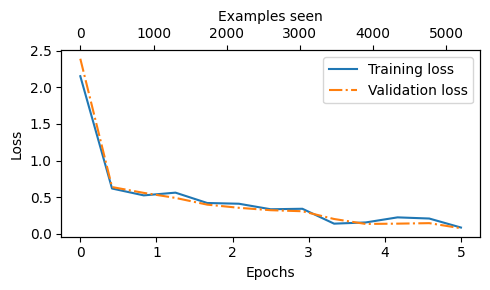

In [38]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5,3))
    
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.", 
        label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()
    
    ax2 = ax1.twiny() # 처리한 샘플 개수를 위해 두 번째 x 축을 만든다.
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")
    
    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()
    
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)
    

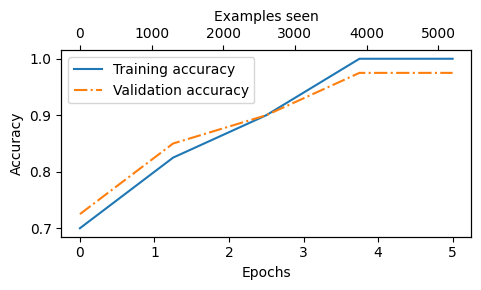

In [39]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy"
)

In [40]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"훈련 정확도: {train_accuracy*100:.2f}%")
print(f"검증 정확도: {val_accuracy*100: .2f}%")
print(f"테스트 정확도: {test_accuracy*100: .2f}%")

훈련 정확도: 97.21%
검증 정확도:  97.32%
테스트 정확도:  95.67%


#### 6.8 LLM을 스팸 분류기로 사용하기  
모델을 미세 튜닝하고 평가했으므로 이제 스팸 메시지를 분류할 차례이다. 미세 튜닝된 GPT 기반 스팸 분류 모델을 사용해보자!  
다음에 나오는 classify_review 함수는 앞서 구현한 SpamDataset에서 사용한 것과 비슷한 데이터 전처리 단계를 수행한다. 그런 다음 텍스트를 토큰 ID로 변화한 후에  
앞에서 했던 것과 비슷하게 모델을 사용해 정수 클래스 레이블을 예측한다. 그런 다음 레이블에 해당하는 클래스의 이름을 반환한다.

In [41]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()
    
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    
    input_ids = input_ids[:min(max_length, supported_context_length)]
    
    assert max_length is not None, (
        "max_length가 지정되지 않았습니다. 모델의 최대 문맥 길이를 사용하려면"
        "max_length=model.pos_emb.weight.shape[0]로 지정하세요."
        )   
    assert max_length <= supported_context_length, (
        f"max_length({max_length})가 모델이 지원하는 문맥 길이 ({supported_context_length})를 초과했습니다"
    )
    
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    
    input_tensor = torch.tensor(
        input_ids, device=device
    ).unsqueeze(0)
    
    with torch.no_grad():
        logits = model(input_tensor)[:,-1,:]
    predicted_label = torch.argmax(logits, dim=-1).item()
    
    return "스팸" if predicted_label == 1 else "스팸 아님"

In [42]:
text_1 = ("You are a winner you have been specially" 
          " selected to receive $1000 cash or $2000 award.")

print(classify_review(text_1, model, tokenizer, device, max_length=train_dataset.max_length))

스팸


In [43]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(text_2, model, tokenizer, device, max_length=train_dataset.max_length))

스팸 아님


In [44]:
torch.save(model.state_dict(), "review_classifier.pth")

In [46]:
model_state_dict = torch.load("review_classifier.pth", map_location=device)
model.load_state_dict(model_state_dict)

<All keys matched successfully>